In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

old = pd.read_parquet('data/ages.pqt')
new = pd.read_parquet('test_ages.pqt')

df = old.merge(new, on='sourceid', suffixes=('_old', '_new'))
print(f'Matched: {len(df)} stars')

Matched: 9477 stars


In [2]:
# Coverage summary
for col in ['log_age_cool', 'log_age']:
    o = np.isfinite(df[f'{col}_old'])
    n = np.isfinite(df[f'{col}_new'])
    print(f'{col}:')
    print(f'  both finite : {(o & n).sum()}')
    print(f'  old only    : {(o & ~n).sum()}')
    print(f'  new only    : {(~o & n).sum()}')
    print(f'  neither     : {(~o & ~n).sum()}')

print()
print('pop_type breakdown:')
print(new['pop_type'].value_counts())

log_age_cool:
  both finite : 9283
  old only    : 4
  new only    : 6
  neither     : 184
log_age:
  both finite : 3284
  old only    : 226
  new only    : 168
  neither     : 5799

pop_type breakdown:
pop_type
thick    8071
thin      766
mixed     640
Name: count, dtype: int64


## Cooling age comparison

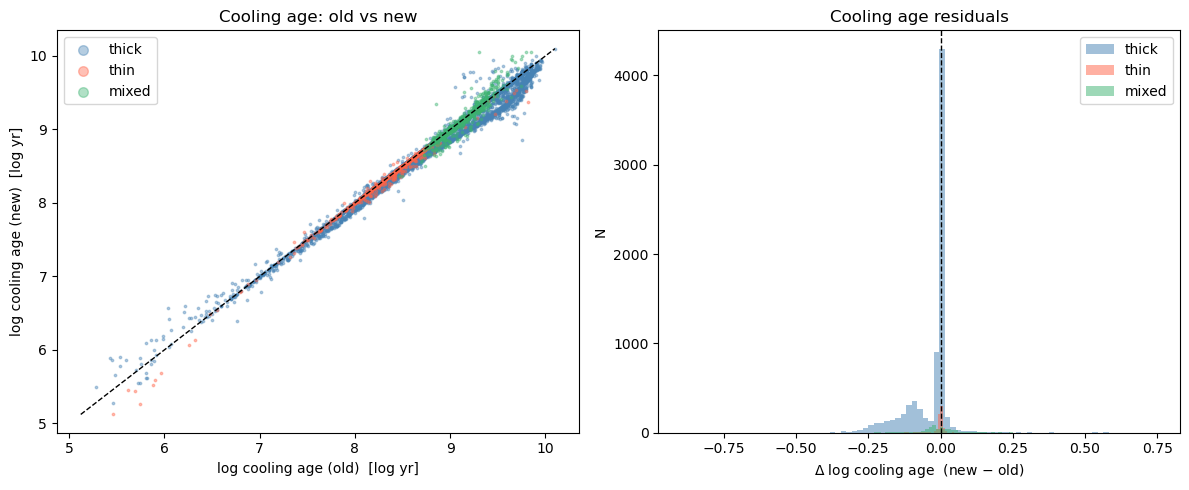

Median residual: -0.0017 dex
Std residual:    0.0798 dex


In [3]:
pop_colors = {'thick': 'steelblue', 'thin': 'tomato', 'mixed': 'mediumseagreen'}

mask = np.isfinite(df['log_age_cool_old']) & np.isfinite(df['log_age_cool_new'])
d = df[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: scatter coloured by pop_type
ax = axes[0]
for pop, col in pop_colors.items():
    m = d['pop_type'] == pop
    ax.scatter(d.loc[m, 'log_age_cool_old'], d.loc[m, 'log_age_cool_new'],
               s=3, alpha=0.4, color=col, label=pop)
lims = [d[['log_age_cool_old','log_age_cool_new']].min().min(),
        d[['log_age_cool_old','log_age_cool_new']].max().max()]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('log cooling age (old)  [log yr]')
ax.set_ylabel('log cooling age (new)  [log yr]')
ax.legend(markerscale=4)
ax.set_title('Cooling age: old vs new')

# right: residual histogram
ax = axes[1]
resid = d['log_age_cool_new'] - d['log_age_cool_old']
for pop, col in pop_colors.items():
    m = d['pop_type'] == pop
    ax.hist(resid[m], bins=80, alpha=0.5, color=col, label=pop, histtype='stepfilled')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel(r'$\Delta$ log cooling age  (new $-$ old)')
ax.set_ylabel('N')
ax.legend()
ax.set_title('Cooling age residuals')

plt.tight_layout()
plt.show()

print(f'Median residual: {resid.median():.4f} dex')
print(f'Std residual:    {resid.std():.4f} dex')

## Total age comparison

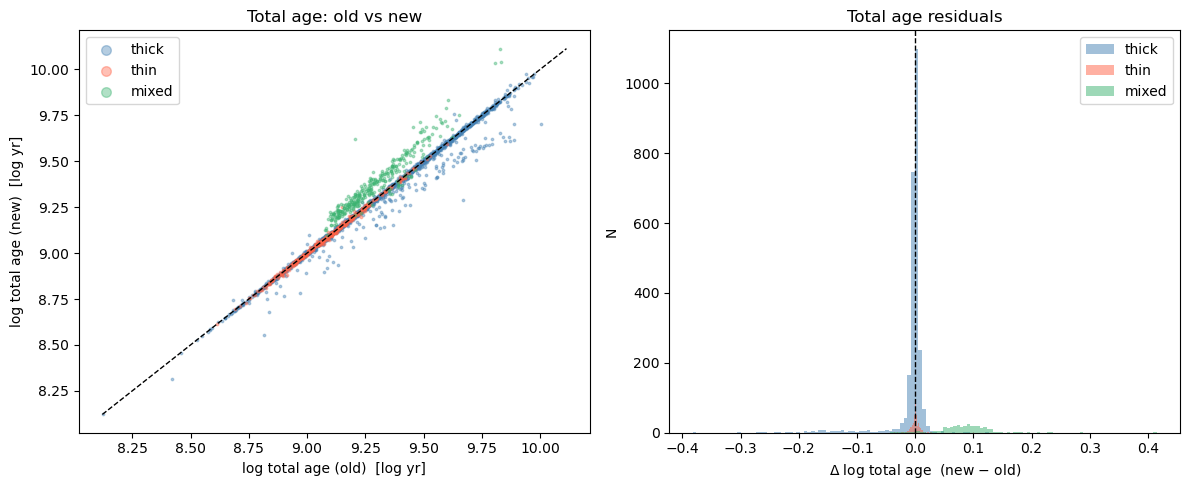

Median residual: 0.0001 dex
Std residual:    0.0417 dex


In [4]:
mask = np.isfinite(df['log_age_old']) & np.isfinite(df['log_age_new'])
d = df[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for pop, col in pop_colors.items():
    m = d['pop_type'] == pop
    ax.scatter(d.loc[m, 'log_age_old'], d.loc[m, 'log_age_new'],
               s=3, alpha=0.4, color=col, label=pop)
lims = [d[['log_age_old','log_age_new']].min().min(),
        d[['log_age_old','log_age_new']].max().max()]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('log total age (old)  [log yr]')
ax.set_ylabel('log total age (new)  [log yr]')
ax.legend(markerscale=4)
ax.set_title('Total age: old vs new')

ax = axes[1]
resid = d['log_age_new'] - d['log_age_old']
for pop, col in pop_colors.items():
    m = d['pop_type'] == pop
    ax.hist(resid[m], bins=80, alpha=0.5, color=col, label=pop, histtype='stepfilled')
ax.axvline(0, color='k', lw=1, ls='--')
ax.set_xlabel(r'$\Delta$ log total age  (new $-$ old)')
ax.set_ylabel('N')
ax.legend()
ax.set_title('Total age residuals')

plt.tight_layout()
plt.show()

print(f'Median residual: {resid.median():.4f} dex')
print(f'Std residual:    {resid.std():.4f} dex')

## High-mass WDs (mass ≥ 1.017 M☉) — Heintz method replaces wdwarfdate

High-mass WDs: 53
  both cooling ages finite: 53


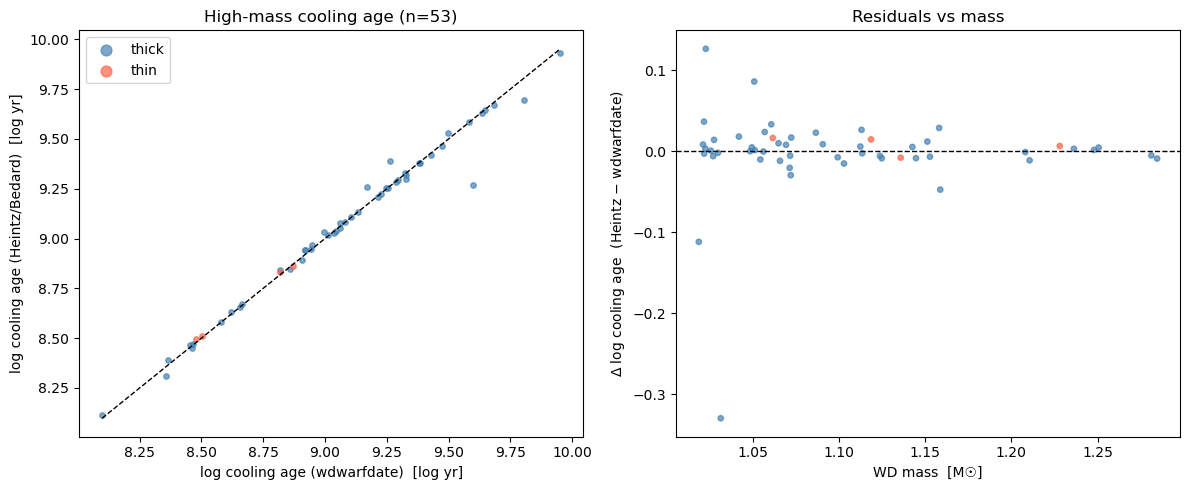

In [5]:
highmass = df['mass_best_new'] >= 1.017626
print(f'High-mass WDs: {highmass.sum()}')

d = df[highmass & np.isfinite(df['log_age_cool_old']) & np.isfinite(df['log_age_cool_new'])]
print(f'  both cooling ages finite: {len(d)}')

if len(d) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    for pop, col in pop_colors.items():
        m = d['pop_type'] == pop
        if m.sum() == 0: continue
        ax.scatter(d.loc[m, 'log_age_cool_old'], d.loc[m, 'log_age_cool_new'],
                   s=15, alpha=0.7, color=col, label=pop)
    lims = [d[['log_age_cool_old','log_age_cool_new']].min().min(),
            d[['log_age_cool_old','log_age_cool_new']].max().max()]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel('log cooling age (wdwarfdate)  [log yr]')
    ax.set_ylabel('log cooling age (Heintz/Bedard)  [log yr]')
    ax.legend(markerscale=2)
    ax.set_title(f'High-mass cooling age (n={len(d)})')

    ax = axes[1]
    ax.scatter(d['mass_best_new'], d['log_age_cool_new'] - d['log_age_cool_old'],
               s=15, alpha=0.7, c=[{'thick':'steelblue','thin':'tomato','mixed':'mediumseagreen'}[p]
                                    for p in d['pop_type']])
    ax.axhline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('WD mass  [M☉]')
    ax.set_ylabel(r'$\Delta$ log cooling age  (Heintz $-$ wdwarfdate)')
    ax.set_title('Residuals vs mass')

    plt.tight_layout()
    plt.show()

## Age distributions: old vs new

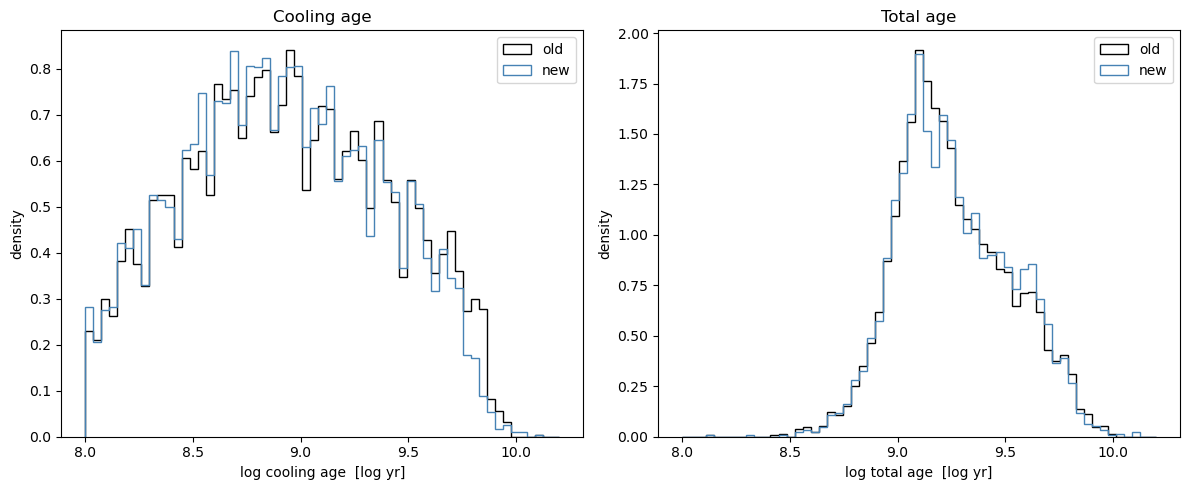

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(axes,
                           ['log_age_cool', 'log_age'],
                           ['Cooling age', 'Total age']):
    bins = np.linspace(8, 10.2, 60)
    o = df[f'{col}_old'].dropna()
    n = df[f'{col}_new'].dropna()
    ax.hist(o, bins=bins, histtype='step', color='k', lw=1.5, label='old', density=True)
    ax.hist(n, bins=bins, histtype='step', color='steelblue', lw=1.5, label='new', density=True)
    ax.set_xlabel(f'log {label.lower()}  [log yr]')
    ax.set_ylabel('density')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.show()